# Задание 1

In [1]:
import os
os.environ['MPLCONFIGDIR'] = 'matplotlib_config'

import pandas as pd
import matplotlib.pyplot as plt

file_name = 'Electronic_sales_Sep2023-Sep2024.csv'
df = pd.read_csv(file_name)

def clean(data):
    data = data.copy()
    data['Purchase Date'] = pd.to_datetime(data['Purchase Date'], errors='coerce')
    for column in ['Total Price', 'Unit Price', 'Quantity', 'Add-on Total']:
        data[column] = pd.to_numeric(data[column], errors='coerce')

    data['Add-ons Purchased'] = data['Add-ons Purchased'].fillna('')
    data['Add-on Total'] = data['Add-on Total'].fillna(0)
    data = data.dropna(subset=['Customer ID', 'Payment Method', 'Purchase Date',
                               'Total Price', 'Unit Price', 'Quantity'])
    data = data[
        data['Order Status'].eq('Completed') &
        data['Total Price'].gt(0) &
        data['Unit Price'].gt(0) &
        data['Quantity'].gt(0)
    ].copy()
    data['order_total'] = data['Total Price'] + data['Add-on Total']
    return data

orders = clean(df)

preferred_payment = (
    orders.groupby(['Customer ID', 'Payment Method'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['Customer ID', 'count', 'Payment Method'],
                 ascending=[True, False, True])
    .drop_duplicates('Customer ID')
    .set_index('Customer ID')['Payment Method']
)

top_customers = (
    orders.groupby('Customer ID')
    .agg(
        total_spent=('order_total', 'sum'),
        addons_spent=('Add-on Total', 'sum'),
        orders_count=('Customer ID', 'size')
    )
    .join(preferred_payment.rename('preferred_payment'))
    .reset_index()
    [['Customer ID', 'preferred_payment', 'total_spent',
      'addons_spent', 'orders_count']]
    .sort_values('total_spent', ascending=False)
    .head(10)
)

top_customers

,Customer ID,preferred_payment,total_spent,addons_spent,orders_count
5048,11476,PayPal,30136.35,198.42,4
7095,15399,PayPal,29390.27,305.39,3
6177,13635,Credit Card,28481.39,388.11,4
7584,16357,Bank Transfer,27838.76,352.75,6
5489,12294,Bank Transfer,27052.70,477.68,4
4960,11332,PayPal,26965.89,240.24,4
839,2556,Debit Card,26329.06,230.66,6
6124,13534,Bank Transfer,26261.21,367.61,5
8030,17236,Credit Card,25167.95,481.93,5
6589,14436,Credit Card,25014.73,102.31,4


# Задание 2

In [2]:
def build_metrics(data):
    columns = ['revenue']
    if data.empty:
        empty = pd.DataFrame(columns=columns)
        return {
            'revenue_by_shipping': empty.copy(),
            'revenue_by_product': empty.copy(),
            'addons_by_month': pd.DataFrame(columns=['addons_revenue']),
            'addons_by_quarter': pd.DataFrame(columns=['addons_revenue']),
            'cohort_revenue': pd.DataFrame(columns=range(4)),
            'cohort_customers': pd.DataFrame(columns=range(4)),
        }

    data = data.copy()
    revenue_by_shipping = (
        data.groupby('Shipping Type')['order_total']
        .sum().sort_values(ascending=False).to_frame('revenue')
    )
    revenue_by_product = (
        data.groupby('Product Type')['order_total']
        .sum().sort_values(ascending=False).to_frame('revenue')
    )

    data['month'] = data['Purchase Date'].dt.to_period('M')
    data['quarter'] = data['Purchase Date'].dt.to_period('Q')
    month_index = pd.period_range(data['month'].min(), data['month'].max(), freq='M')
    addons_by_month = (
        data.groupby('month')['Add-on Total'].sum()
        .reindex(month_index, fill_value=0).to_frame('addons_revenue')
    )
    addons_by_quarter = (
        data.groupby('quarter')['Add-on Total'].sum()
        .to_frame('addons_revenue')
    )

    data['cohort'] = data.groupby('Customer ID')['month'].transform('min')
    data['cohort_month'] = (
        (data['month'].dt.year - data['cohort'].dt.year) * 12 +
        data['month'].dt.month - data['cohort'].dt.month
    )
    cohort_data = data[data['cohort_month'].between(0, 3)]
    cohort_revenue = cohort_data.pivot_table(
        index='cohort', columns='cohort_month', values='order_total',
        aggfunc='sum', fill_value=0
    ).reindex(columns=range(4))
    cohort_customers = cohort_data.pivot_table(
        index='cohort', columns='cohort_month', values='Customer ID',
        aggfunc='nunique', fill_value=0
    ).reindex(columns=range(4))

    return {
        'revenue_by_shipping': revenue_by_shipping,
        'revenue_by_product': revenue_by_product,
        'addons_by_month': addons_by_month,
        'addons_by_quarter': addons_by_quarter,
        'cohort_revenue': cohort_revenue,
        'cohort_customers': cohort_customers,
    }

metrics = build_metrics(orders)

display(metrics['revenue_by_shipping'])
display(metrics['revenue_by_product'])
display(metrics['addons_by_month'].head())
display(metrics['addons_by_quarter'])
display(metrics['cohort_revenue'])
display(metrics['cohort_customers'])

,revenue
Shipping Type,
Standard,14676351.95
Expedited,8610437.09
Same Day,8469574.60
Overnight,5982983.40
Express,5725863.77


,revenue
Product Type,
Smartphone,14630325.53
Smartwatch,9557416.02
Laptop,8536583.03
Tablet,7893431.51
Headphones,2847454.72


,addons_revenue
2023-09,5337.61
2023-10,26153.21
2023-11,24453.33
2023-12,22750.23
2024-01,93254.95


,addons_revenue
quarter,
2023Q3,5337.61
2023Q4,73356.77
2024Q1,258222.60
2024Q2,256316.84
2024Q3,242361.42


cohort_month,0,1,2,3
cohort,,,,
2023-09,288973.36,33966.24,27171.95,33728.93
2023-10,1547512.83,57546.84,105708.66,105318.56
2023-11,1329851.04,51831.74,120410.29,49399.43
2023-12,1141503.77,70631.39,51051.53,66268.75
2024-01,4300575.58,224810.52,363311.35,367531.56
2024-02,3551138.51,237765.99,258807.13,276145.83
2024-03,3492721.17,309227.62,249389.13,247959.27
2024-04,3176736.50,255450.10,270533.88,246163.28
2024-05,3129140.50,184409.51,242471.91,186356.86


cohort_month,0,1,2,3
cohort,,,,
2023-09,121,11,12,12
2023-10,581,27,35,36
2023-11,482,21,39,24
2023-12,442,27,16,23
2024-01,1236,72,88,88
2024-02,1029,65,71,75
2024-03,1028,77,71,72
2024-04,907,76,73,63
2024-05,906,53,66,50


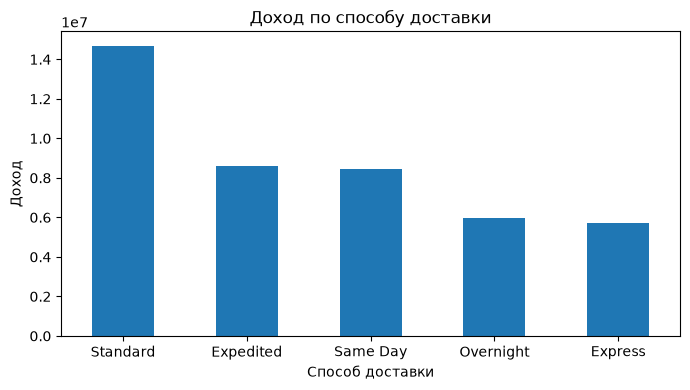

In [3]:
metrics['revenue_by_shipping'].plot(kind='bar', legend=False, figsize=(7, 4))
plt.title('Доход по способу доставки')
plt.xlabel('Способ доставки')
plt.ylabel('Доход')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

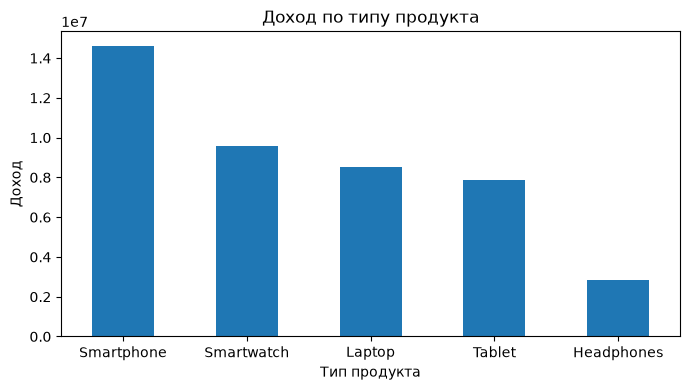

In [4]:
metrics['revenue_by_product'].plot(kind='bar', legend=False, figsize=(7, 4))
plt.title('Доход по типу продукта')
plt.xlabel('Тип продукта')
plt.ylabel('Доход')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

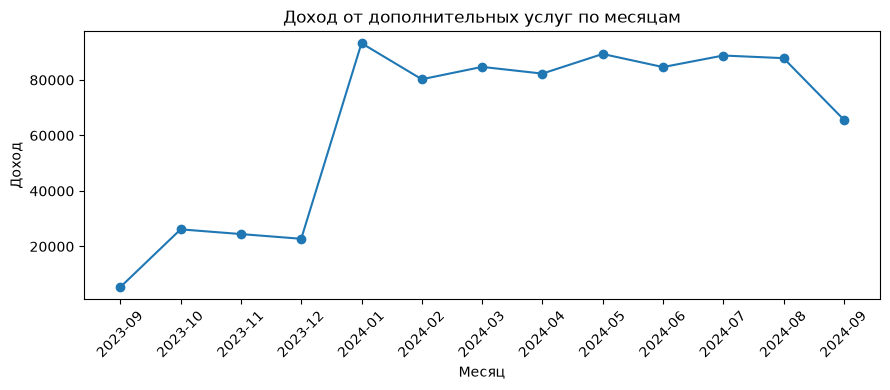

In [5]:
addons = metrics['addons_by_month']
plt.figure(figsize=(9, 4))
plt.plot(addons.index.astype(str), addons['addons_revenue'], marker='o')
plt.title('Доход от дополнительных услуг по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Доход')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

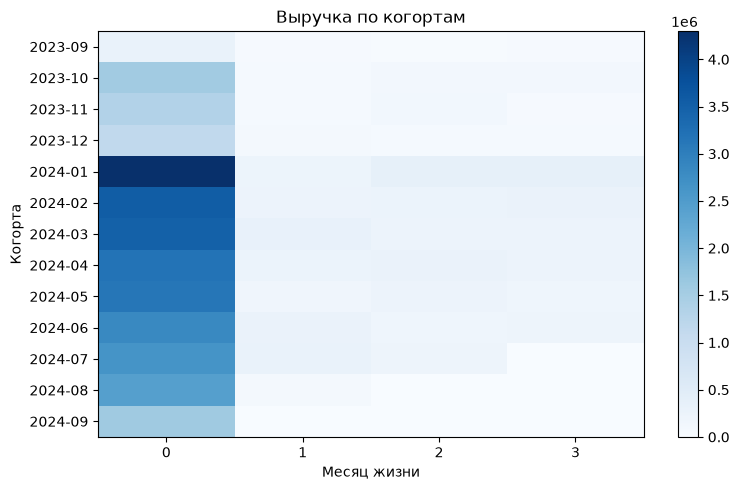

In [6]:
cohort = metrics['cohort_revenue']
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(cohort, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(cohort.columns)), labels=cohort.columns)
ax.set_yticks(range(len(cohort.index)), labels=cohort.index.astype(str))
fig.colorbar(image, ax=ax)
ax.set_title('Выручка по когортам')
ax.set_xlabel('Месяц жизни')
ax.set_ylabel('Когорта')
plt.tight_layout()
plt.show()

In [7]:
shipping = metrics['revenue_by_shipping']['revenue'].idxmax()
product = metrics['revenue_by_product']['revenue'].idxmax()
month = metrics['addons_by_month']['addons_revenue'].idxmax()

print(f'Больше всего дохода приносит способ доставки: {shipping}.')
print(f'Самый доходный тип продукта: {product}.')
print(f'Максимальный доход от дополнительных услуг был в {month}.')

Больше всего дохода приносит способ доставки: Standard.
Самый доходный тип продукта: Smartphone.
Максимальный доход от дополнительных услуг был в 2024-01.
